# Applying Pretrained Vision Models across Different Image Domains
### A Source-Only Evaluation on the Office-Home Dataset

## Abstract
This study evaluates the transferability of ImageNet-pretrained vision models across image domains with a shared label space. ResNet18 and ResNet50 are trained on the Real-World domain of Office-Home and evaluated on held-out images from the Art, Clipart, Product, and Real-World domains. Two training strategies are compared: a frozen backbone with a trainable classification head, and fine-tuning of the final residual block and classification head. Performance is measured using accuracy, macro-averaged F1, and the difference between same-domain and cross-domain accuracy.

## Research objectives
1. Measure classification performance when training and test images belong to different domains.
2. Compare the cross-domain performance of ResNet18 and ResNet50.
3. Assess whether fine-tuning the final residual block improves performance relative to a frozen backbone.

## Experimental protocol
The experiment uses the 65 shared object classes in Office-Home. Images within each domain and class are partitioned into approximately 70% training, 15% validation, and 15% test subsets. All model configurations share the same data partitions. Model selection and early stopping use only source-domain validation macro-F1. Target-domain training and validation subsets are excluded from optimization and checkpoint selection.

The default design contains four configurations: two architectures and two training strategies. This is a source-only domain generalization experiment with a custom held-out evaluation protocol, rather than the standard Office-Home domain adaptation benchmark. The implementation uses PyTorch and mixed-precision computation with 224 × 224 input images on a CUDA GPU.

## 1. Dependencies
The experiment uses PyTorch and torchvision for model training, scikit-learn for evaluation, and pandas, Matplotlib, and seaborn for reporting. Hugging Face Hub and PyArrow support automatic acquisition and extraction of the dataset mirror. The existing Colab PyTorch installation is retained to preserve compatibility with the CUDA runtime.

In [1]:
%pip -q install huggingface_hub pyarrow requests pyyaml scikit-learn pandas matplotlib seaborn tqdm pillow

In [2]:
import os, sys, json, random, time, gc, hashlib, shutil, zipfile, platform
from pathlib import Path
from contextlib import nullcontext
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm.auto import tqdm
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision import models, transforms
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from IPython.display import display

assert torch.cuda.is_available(), 'Select Runtime → Change runtime type → T4 GPU, then rerun.'
DEVICE = torch.device('cuda')
print('GPU:', torch.cuda.get_device_name(0))
print('torch:', torch.__version__, '| torchvision:', torchvision.__version__)
print('VRAM:', round(torch.cuda.get_device_properties(0).total_memory / 2**30, 1), 'GiB')


GPU: Tesla T4
torch: 2.11.0+cu130 | torchvision: 0.26.0+cu130
VRAM: 14.6 GiB


## 2. Experimental configuration
The configuration defines source domains, architectures, training strategies, random seeds, batch size, learning rates, and early stopping. Results and checkpoints are stored in the Colab runtime, separately from the locally extracted dataset. The compact results archive is downloaded automatically at the end of the run. Checkpoints are not included in that archive and remain on the runtime disk; they are lost if the runtime is deleted.

The default run uses seed 42. Multiple seeds can be specified to quantify training variability. The smoke-test option is intended only for implementation verification and is excluded from substantive performance analysis. Saving checkpoints preserves the best validation-selected model and enables recovery of interrupted training runs.

In [3]:
LOCAL_DATA = Path('/content/officehome_data')
SOURCE_DOMAINS = ['Real_World']
DOMAINS = ['Art', 'Clipart', 'Product', 'Real_World']
MODEL_NAMES = ['resnet18', 'resnet50']
MODES = ['linear_probe', 'finetune_last_block']
SEEDS = [42]
SPLIT_SEED = 2026
BATCH_SIZE = 32
NUM_WORKERS = 2
EPOCHS = {'linear_probe': 15, 'finetune_last_block': 20}
PATIENCE = 5
HEAD_LR = 1e-3
BACKBONE_LR = 1e-4
WEIGHT_DECAY = 1e-4
SAVE_CHECKPOINTS = True
RESUME = True
SMOKE_TEST = False
# Check byte-identical images across the entire dataset to prevent duplicate leakage across splits/domains.
CHECK_EXACT_DUPLICATES = True

BASE_OUTPUT = Path('/content/OfficeHome_DomainShift_T4')
BASE_OUTPUT.mkdir(parents=True, exist_ok=True)
LOCAL_DATA.mkdir(parents=True, exist_ok=True)
assert set(SOURCE_DOMAINS) <= set(DOMAINS)
assert MODEL_NAMES and set(MODEL_NAMES) <= {'resnet18', 'resnet50'}
assert MODES and set(MODES) <= {'linear_probe', 'finetune_last_block'}

def seed_everything(seed):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

def atomic_torch_save(obj, path):
    path = Path(path)
    tmp = path.with_suffix(path.suffix + '.tmp')
    torch.save(obj, tmp)
    os.replace(tmp, path)

print('Output:', BASE_OUTPUT)

Output: /content/OfficeHome_DomainShift_T4


## 3. Automatic dataset acquisition
Office-Home is acquired from the public `flwrlabs/office-home` mirror on Hugging Face. The dataset version is pinned to commit `2a083645e3177afbd91ba4fa2651238f8994d335`. Three Parquet shards contain 15,588 embedded images and their domain and class labels.

Shard sizes and SHA-256 checksums are verified before extraction. Images are extracted in small batches while retaining their original encoded bytes. The four domains and 65 classes are then validated by the partitioning procedure. Downloads use the Hub client, with automatic retries and a direct HTTPS fallback. Authentication, Google Drive access, and manual archive uploads are not required.

In [4]:
# Public, version-pinned dataset mirror. No login, Drive mount, or manual upload.
os.environ['HF_HUB_DISABLE_IMPLICIT_TOKEN'] = '1'
os.environ['HF_HUB_DISABLE_XET'] = '1'
os.environ['HF_HUB_DOWNLOAD_TIMEOUT'] = '120'
from huggingface_hub import hf_hub_download
import pyarrow.parquet as pq
import requests
import yaml
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry

DATASET_REPO = 'flwrlabs/office-home'
DATASET_REVISION = '2a083645e3177afbd91ba4fa2651238f8994d335'
EXPECTED_IMAGES = 15588
SHARDS = {
    'data/train-00000-of-00003.parquet': (248782886, 'a2519afebd495007309a3b8252a8f1eb8b1075c74a5e423fea54d24487e1edb1'),
    'data/train-00001-of-00003.parquet': (119438711, '8ce4a279c2fdf36ce3b84f3b00831c54ccc98dc0b4317af4891a819f6d66aab1'),
    'data/train-00002-of-00003.parquet': (790762518, '76eacc8b09fcf352e163a781c71460477462d246f842839bc977539444623330'),
}
DOWNLOAD_CACHE = Path('/content/officehome_download_cache')
DOWNLOAD_CACHE.mkdir(parents=True, exist_ok=True)
DATA_ROOT = LOCAL_DATA / 'officehome_hf'
COMPLETE_MARKER = DATA_ROOT / 'dataset_complete.json'

def file_sha256(path):
    digest = hashlib.sha256()
    with open(path, 'rb') as stream:
        for chunk in iter(lambda: stream.read(2**20), b''):
            digest.update(chunk)
    return digest.hexdigest()

session = requests.Session()
retry = Retry(total=3, backoff_factor=1, status_forcelist=[429,500,502,503,504])
session.mount('https://', HTTPAdapter(max_retries=retry))

def direct_download(filename):
    # HTTP fallback for Hub client errors; interrupted partial downloads are never reused.
    target = DOWNLOAD_CACHE / Path(filename).name
    temporary = target.with_suffix(target.suffix + '.partial')
    url = f'https://huggingface.co/datasets/{DATASET_REPO}/resolve/{DATASET_REVISION}/{filename}?download=true'
    with session.get(url, stream=True, timeout=(30,120)) as response:
        response.raise_for_status()
        total = int(response.headers.get('Content-Length',0)) or None
        with temporary.open('wb') as output, tqdm(total=total, unit='B', unit_scale=True,
                                                     desc=Path(filename).name) as bar:
            for chunk in response.iter_content(chunk_size=2**20):
                if chunk:
                    output.write(chunk); bar.update(len(chunk))
    os.replace(temporary,target)
    return target

def download_verified(filename, expected=None):
    local = DOWNLOAD_CACHE / Path(filename).name
    last_error = None
    for attempt in range(3):
        try:
            if local.is_file():
                candidate = local
            elif attempt == 0:
                candidate = Path(hf_hub_download(repo_id=DATASET_REPO, filename=filename,
                                repo_type='dataset', revision=DATASET_REVISION, token=False))
            else:
                candidate = direct_download(filename)
            if expected is not None:
                size, checksum = expected
                if candidate.stat().st_size != size or file_sha256(candidate) != checksum:
                    if candidate == local: local.unlink(missing_ok=True)
                    raise ValueError(f'Integrity check failed: {filename}')
            return candidate
        except Exception as error:
            last_error = error
            print(f'Download retry {attempt+1}/3 for {filename}: {type(error).__name__}')
            if attempt < 2: time.sleep(2)
    raise RuntimeError(f'Automatic dataset download failed after retries: {filename}. '
                       'The public host may be temporarily unavailable. Rerun this cell to retry.') from last_error

def canonical_domain(value):
    key = ''.join(ch for ch in str(value).lower() if ch.isalnum())
    mapping = {'art':'Art','clipart':'Clipart','product':'Product','realworld':'Real_World'}
    if key not in mapping: raise ValueError(f'Unexpected domain: {value}')
    return mapping[key]

def read_class_names(readme_path):
    text = Path(readme_path).read_text()
    metadata = yaml.safe_load(text.split('---',2)[1])
    features = metadata['dataset_info']['features']
    names = next(f for f in features if f['name']=='label')['dtype']['class_label']['names']
    if isinstance(names, dict):
        names = [v for _,v in sorted(names.items(),key=lambda item:int(item[0]))]
    assert len(names)==65 and len(set(names))==65
    assert all('/' not in name and '\\' not in name and name not in {'.','..'} for name in names)
    return names

def materialize_parquet(shard_paths, class_names, root):
    # Preserve original image bytes instead of re-encoding images.
    count = 0
    for shard in shard_paths:
        parquet = pq.ParquetFile(shard)
        assert {'image','domain','label'} <= set(parquet.schema_arrow.names)
        for batch in tqdm(parquet.iter_batches(batch_size=32, columns=['image','domain','label']),
                          total=(parquet.metadata.num_rows+31)//32,desc=f'Extract {Path(shard).name}'):
            for row in batch.to_pylist():
                domain = canonical_domain(row['domain'])
                label = int(row['label'])
                assert 0 <= label < len(class_names)
                folder = root / domain / class_names[label]
                folder.mkdir(parents=True,exist_ok=True)
                image = row['image']
                payload = image.get('bytes') if isinstance(image,dict) else image
                if not payload:
                    raise ValueError('Expected embedded image bytes in the dataset mirror.')
                destination = folder / f'{count:06d}.jpg'
                if not destination.exists() or destination.stat().st_size != len(payload):
                    temporary = destination.with_suffix('.partial')
                    temporary.write_bytes(payload)
                    os.replace(temporary,destination)
                count += 1
    return count

cached = False
if COMPLETE_MARKER.exists():
    try:
        info = json.loads(COMPLETE_MARKER.read_text())
        cached = (info['repo']==DATASET_REPO and info['revision']==DATASET_REVISION and
                  info['images']==EXPECTED_IMAGES and len(list(DATA_ROOT.rglob('*.jpg')))==EXPECTED_IMAGES and
                  all((DATA_ROOT/d).is_dir() for d in DOMAINS))
    except (OSError,ValueError,KeyError):
        cached = False
if not cached:
    # A different dataset version is rebuilt; an interrupted extraction of this version resumes.
    if COMPLETE_MARKER.exists() and DATA_ROOT.exists(): shutil.rmtree(DATA_ROOT)
    readme_path = download_verified('README.md')
    mirror_classes = read_class_names(readme_path)
    shard_paths = [download_verified(name,expected) for name,expected in SHARDS.items()]
    total_rows = sum(pq.ParquetFile(path).metadata.num_rows for path in shard_paths)
    assert total_rows==EXPECTED_IMAGES, f'Unexpected row count: {total_rows}'
    extracted = materialize_parquet(shard_paths,mirror_classes,DATA_ROOT)
    assert extracted==EXPECTED_IMAGES
    assert len(list(DATA_ROOT.rglob('*.jpg')))==EXPECTED_IMAGES
    COMPLETE_MARKER.write_text(json.dumps(dict(repo=DATASET_REPO,revision=DATASET_REVISION,
                                              images=extracted,class_names=mirror_classes),indent=2))
session.close()
print('Dataset ready:',DATA_ROOT)
print('Images:',EXPECTED_IMAGES,'| Domains:',len(DOMAINS),'| Classes: 65')

Dataset ready: /content/officehome_data/officehome_hf
Images: 15588 | Domains: 4 | Classes: 65


## 4. Data validation and partitioning
Images are decoded to detect corrupted files. Byte-identical duplicates are removed across the complete dataset before partitioning. Retained images are split within each domain and class using a fixed random seed, with at least one validation and test image per class.

A manifest records image paths, domain labels, class labels, file hashes, and split assignments. A configuration fingerprint separates outputs from different experimental settings. Class mappings are checked for consistency across domains. Byte-level deduplication does not detect near-duplicate images or modified copies.

In [5]:
classes = sorted(p.name for p in (DATA_ROOT / 'Real_World').iterdir() if p.is_dir())
assert len(classes) == 65, f'Expected 65 Office-Home classes; found {len(classes)}.'
class_to_idx = {name: i for i, name in enumerate(classes)}
records, rejected, duplicates = [], [], []
seen_hashes = {}
for domain in DOMAINS:
    domain_classes = sorted(p.name for p in (DATA_ROOT / domain).iterdir() if p.is_dir())
    assert domain_classes == classes, f'Class names do not match: {domain}'
    paths = sorted(p for p in (DATA_ROOT / domain).rglob('*') if p.suffix.lower() in {'.jpg','.jpeg','.png','.bmp'})
    for p in tqdm(paths, desc=f'Validate {domain}'):
        try:
            with Image.open(p) as im:
                im.convert('RGB').load()
            digest = hashlib.sha256(p.read_bytes()).hexdigest() if CHECK_EXACT_DUPLICATES else str(p.relative_to(DATA_ROOT))
            if digest in seen_hashes:
                duplicates.append({'removed':str(p.relative_to(DATA_ROOT)), 'kept':seen_hashes[digest]})
                continue
            rel = str(p.relative_to(DATA_ROOT))
            seen_hashes[digest] = rel
            records.append({'relative_path':rel,'domain':domain,'class_name':p.parent.name,
                            'label':class_to_idx[p.parent.name], 'sha256':digest})
        except Exception as exc:
            rejected.append({'path':str(p), 'reason':str(exc)})
manifest = pd.DataFrame(records)
assert not manifest.empty
rng = np.random.default_rng(SPLIT_SEED)
parts = []
for (domain, label), group in manifest.groupby(['domain','label'], sort=True):
    group = group.sort_values('relative_path').reset_index(drop=True)
    n = len(group)
    assert n >= 3, f'Insufficient images for splitting: {domain}, {classes[label]}'
    order = rng.permutation(n)
    n_val = max(1, int(round(n * .15)))
    n_test = max(1, int(round(n * .15)))
    group['split'] = 'train'
    group.loc[order[:n_val], 'split'] = 'val'
    group.loc[order[n_val:n_val+n_test], 'split'] = 'test'
    parts.append(group)
manifest = pd.concat(parts, ignore_index=True)
assert manifest.relative_path.is_unique
if CHECK_EXACT_DUPLICATES:
    assert manifest.sha256.is_unique
assert (manifest.groupby(['domain','split']).label.nunique() == 65).all()
manifest_digest = hashlib.sha256(manifest.to_csv(index=False).encode()).hexdigest()
config = dict(dataset_repo=DATASET_REPO, dataset_revision=DATASET_REVISION, protocol='source_only_v1', source_domains=SOURCE_DOMAINS, models=MODEL_NAMES,
              modes=MODES, seeds=SEEDS, split_seed=SPLIT_SEED, batch_size=BATCH_SIZE,
              epochs=EPOCHS, num_workers=NUM_WORKERS, patience=PATIENCE, head_lr=HEAD_LR, backbone_lr=BACKBONE_LR,
              weight_decay=WEIGHT_DECAY, smoke_test=SMOKE_TEST,
              check_exact_duplicates=CHECK_EXACT_DUPLICATES, manifest_digest=manifest_digest,
              torch_version=torch.__version__, torchvision_version=torchvision.__version__,
              preprocessing='resize256_centercrop224_imagenet;train_randomcrop_flip',
              batchnorm='running_stats_frozen')
run_hash = hashlib.sha256(json.dumps(config, sort_keys=True).encode()).hexdigest()[:12]
OUT = BASE_OUTPUT / ('smoke_' + run_hash if SMOKE_TEST else 'run_' + run_hash)
OUT.mkdir(parents=True, exist_ok=True)
manifest.to_csv(OUT / 'split_manifest.csv', index=False)
pd.DataFrame(rejected).to_csv(OUT / 'rejected_images.csv', index=False)
pd.DataFrame(duplicates).to_csv(OUT / 'exact_duplicates_removed.csv', index=False)
(OUT / 'config.json').write_text(json.dumps(config, indent=2))
(OUT / 'class_to_idx.json').write_text(json.dumps(class_to_idx, indent=2))
(OUT / 'environment.json').write_text(json.dumps(dict(python=sys.version, platform=platform.platform(),
                                      gpu=torch.cuda.get_device_name(0)), indent=2))
display(pd.crosstab(manifest.domain, manifest.split))
print('Corrupted:',len(rejected),'| Byte-identical duplicates removed:',len(duplicates),'| Output:', OUT)

split,test,train,val
domain,,,
Art,349,1617,349
Clipart,646,2960,646
Product,646,2985,646
Real_World,651,3030,651


Corrupted: 0 | Byte-identical duplicates removed: 412 | Output: /content/OfficeHome_DomainShift_T4/run_5765dc922429


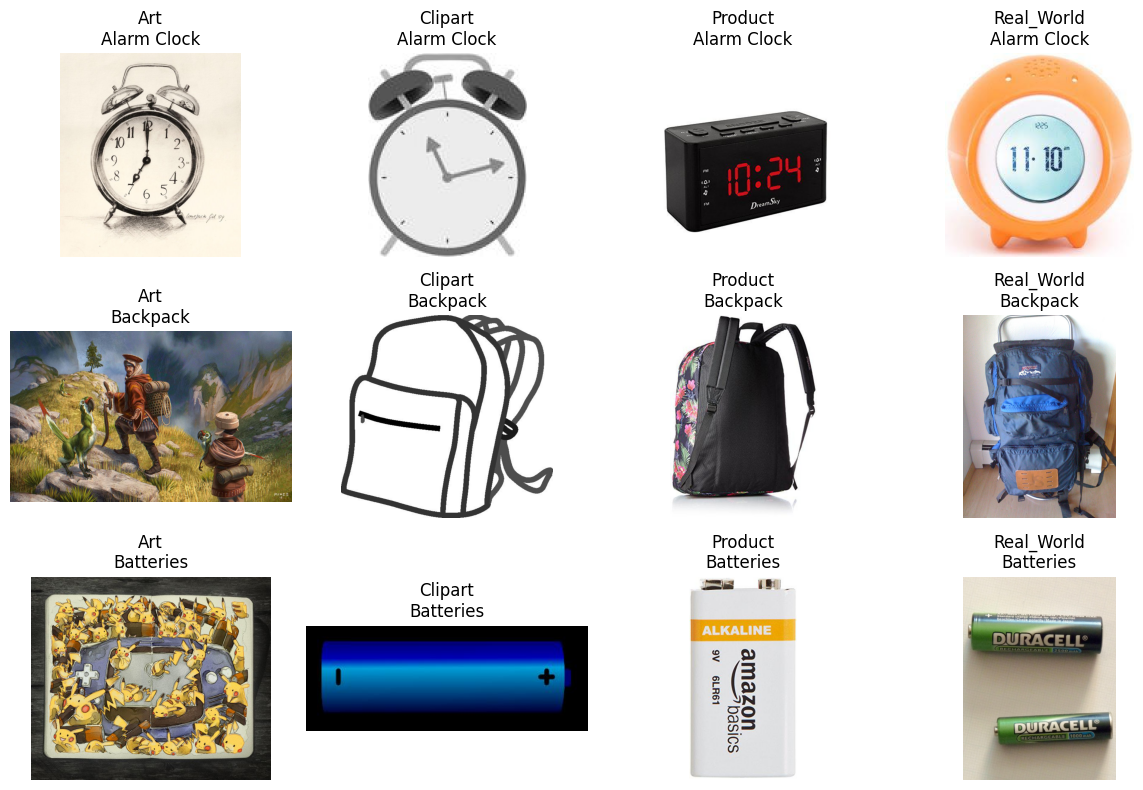

In [6]:
# Show the same class in all four domains.
example_classes = classes[:3]
fig, axes = plt.subplots(len(example_classes), len(DOMAINS), figsize=(12, 8))
for i, name in enumerate(example_classes):
    for j, domain in enumerate(DOMAINS):
        row = manifest[(manifest.domain == domain) & (manifest.class_name == name)].iloc[0]
        with Image.open(DATA_ROOT / row.relative_path) as im:
            axes[i,j].imshow(im.convert('RGB'))
        axes[i,j].set_title(f'{domain}\n{name.replace("_", " ")}'); axes[i,j].axis('off')
plt.tight_layout(); plt.savefig(OUT / 'domain_examples.png', dpi=160); plt.show()


## 5. Preprocessing and model construction
Training images undergo random resized cropping and horizontal flipping. Validation and test images are resized and center-cropped deterministically. All inputs are normalized using ImageNet channel statistics.

Both architectures use torchvision's `IMAGENET1K_V1` weights and a new 65-class linear classification head. In the frozen-backbone strategy, only the head is optimized. In the fine-tuning strategy, the final residual block (`layer4`) and head are optimized. BatchNorm running statistics remain fixed in both strategies. All other backbone parameters remain frozen.

In [7]:
MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.7,1.0)),
    transforms.RandomHorizontalFlip(), transforms.ToTensor(), transforms.Normalize(MEAN, STD)])
eval_transform = transforms.Compose([
    transforms.Resize(256), transforms.CenterCrop(224),
    transforms.ToTensor(), transforms.Normalize(MEAN, STD)])

class OfficeDataset(Dataset):
    def __init__(self, frame, transform):
        self.frame = frame.reset_index(drop=True).copy()
        self.transform = transform
    def __len__(self): return len(self.frame)
    def __getitem__(self, idx):
        row = self.frame.iloc[idx]
        with Image.open(DATA_ROOT / row.relative_path) as im:
            x = self.transform(im.convert('RGB'))
        return x, int(row.label), row.relative_path

def get_frame(domain, split):
    frame = manifest[(manifest.domain == domain) & (manifest.split == split)].copy()
    if SMOKE_TEST:
        frame = frame.groupby('label', group_keys=False).head(2)
    return frame.reset_index(drop=True)

def seed_worker(worker_id):
    s = torch.initial_seed() % 2**32
    np.random.seed(s); random.seed(s)

def make_loader(frame, training, seed):
    generator = torch.Generator().manual_seed(seed)
    return DataLoader(OfficeDataset(frame, train_transform if training else eval_transform),
                      batch_size=BATCH_SIZE, shuffle=training, num_workers=NUM_WORKERS,
                      pin_memory=True, persistent_workers=False,
                      worker_init_fn=seed_worker, generator=generator, drop_last=False)

def build_model(name, mode, pretrained=True):
    constructors = {'resnet18':(models.resnet18, models.ResNet18_Weights.IMAGENET1K_V1),
                    'resnet50':(models.resnet50, models.ResNet50_Weights.IMAGENET1K_V1)}
    constructor, weights = constructors[name]
    model = constructor(weights=weights if pretrained else None)
    for p in model.parameters(): p.requires_grad = False
    model.fc = nn.Linear(model.fc.in_features, len(classes))
    if mode == 'finetune_last_block':
        for p in model.layer4.parameters(): p.requires_grad = True
    elif mode != 'linear_probe':
        raise ValueError(mode)
    return model.to(DEVICE)

def training_mode(model, mode):
    # Frozen backbone stays in eval, including BatchNorm. layer4 is trainable for fine-tuning.
    model.eval(); model.fc.train()
    if mode == 'finetune_last_block':
        model.layer4.train()
        for module in model.modules():
            if isinstance(module, nn.modules.batchnorm._BatchNorm): module.eval()

loss_fn = nn.CrossEntropyLoss()
def amp_context():
    return torch.autocast(device_type='cuda', dtype=torch.float16)

@torch.inference_mode()
def evaluate(model, loader):
    model.eval()
    true, pred, confidence, paths = [], [], [], []
    total_loss, n = 0., 0
    for x, y, batch_paths in loader:
        x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)
        with amp_context():
            logits = model(x)
            loss = loss_fn(logits, y)
        probs = logits.float().softmax(dim=1)
        conf, guess = probs.max(dim=1)
        total_loss += loss.item()*len(y); n += len(y)
        true.extend(y.cpu().tolist()); pred.extend(guess.cpu().tolist())
        confidence.extend(conf.cpu().tolist()); paths.extend(batch_paths)
    metrics = dict(loss=total_loss/n, accuracy=accuracy_score(true,pred),
                   macro_f1=f1_score(true,pred,labels=list(range(len(classes))),average='macro',zero_division=0), n=n)
    predictions = pd.DataFrame(dict(relative_path=paths, y_true=true, y_pred=pred, confidence=confidence))
    return metrics, predictions


## 6. Optimization and model selection
Models are optimized using AdamW and cross-entropy loss, with cosine learning-rate scheduling and mixed-precision gradient scaling. The classification head and fine-tuned residual block use separate learning rates. Gradient norms are clipped to 1.0.

Early stopping monitors source-validation macro-F1. The checkpoint with the highest source-validation macro-F1 is retained for final evaluation. Target test sets are evaluated only after training and checkpoint selection. Recovery checkpoints preserve model parameters, optimizer and scheduler states, the gradient scaler, training history, and random states.

In [8]:
def fit_one(source, name, mode, seed):
    seed_everything(seed)
    exp = OUT / f'{source}__{name}__{mode}__seed{seed}'
    exp.mkdir(parents=True, exist_ok=True)
    model = build_model(name, mode)
    groups = [{'params':model.fc.parameters(), 'lr':HEAD_LR}]
    if mode == 'finetune_last_block':
        groups.append({'params':model.layer4.parameters(), 'lr':BACKBONE_LR})
    optimizer = torch.optim.AdamW(groups, weight_decay=WEIGHT_DECAY)
    max_epochs = 1 if SMOKE_TEST else EPOCHS[mode]
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max_epochs)
    scaler = torch.amp.GradScaler('cuda')
    start, best, bad, history, best_state = 0, -1., 0, [], None
    last_path, best_path = exp / 'last.pt', exp / 'best.pt'
    done_path = exp / 'training_complete.json'
    if not RESUME:
        for p in [last_path, best_path, done_path]: p.unlink(missing_ok=True)
    if SAVE_CHECKPOINTS and RESUME and last_path.exists():
        ck = torch.load(last_path, map_location='cpu', weights_only=False)
        assert ck['config_hash'] == run_hash and ck['classes'] == classes
        model.load_state_dict(ck['model'])
        optimizer.load_state_dict(ck['optimizer'])
        scheduler.load_state_dict(ck['scheduler']); scaler.load_state_dict(ck['scaler'])
        start, best, bad, history = ck['next_epoch'], ck['best_f1'], ck['bad_epochs'], ck['history']
        random.setstate(ck['python_rng']); np.random.set_state(ck['numpy_rng'])
        torch.set_rng_state(ck['torch_rng']); torch.cuda.set_rng_state_all(ck['cuda_rng'])
        del ck
        print('Resume:', exp.name, 'epoch',start+1)
    train_frame, val_frame = get_frame(source,'train'), get_frame(source,'val')
    val_loader = make_loader(val_frame,False,seed)
    if not (SAVE_CHECKPOINTS and RESUME and done_path.exists() and best_path.exists()):
        for epoch in range(start, max_epochs):
            if bad >= PATIENCE: break
            # Epoch-derived loader seed makes shuffle reproducible after reconnecting.
            train_loader = make_loader(train_frame,True,seed+epoch)
            training_mode(model,mode)
            total, correct, n = 0., 0, 0
            t0 = time.perf_counter()
            progress = tqdm(train_loader, desc=f'{name}/{mode} {epoch+1}/{max_epochs}')
            for x,y,_ in progress:
                x,y = x.to(DEVICE,non_blocking=True),y.to(DEVICE,non_blocking=True)
                optimizer.zero_grad(set_to_none=True)
                with amp_context():
                    logits = model(x); loss = loss_fn(logits,y)
                if not torch.isfinite(loss):
                    raise RuntimeError('Nonfinite loss. Check the data or reduce the learning rate.')
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                nn.utils.clip_grad_norm_([p for p in model.parameters() if p.requires_grad],1.)
                scaler.step(optimizer); scaler.update()
                total += loss.item()*len(y); correct += (logits.argmax(1)==y).sum().item(); n += len(y)
                progress.set_postfix(loss=f'{total/n:.3f}')
            vm,_ = evaluate(model,val_loader)
            scheduler.step()
            row = dict(epoch=epoch+1,train_loss=total/n,train_accuracy=correct/n,
                       val_loss=vm['loss'],val_accuracy=vm['accuracy'],val_macro_f1=vm['macro_f1'],
                       seconds=time.perf_counter()-t0)
            history.append(row)
            improved = vm['macro_f1'] > best + 1e-6
            if improved:
                best, bad = vm['macro_f1'],0
                best_state = {k:v.detach().cpu().clone() for k,v in model.state_dict().items()}
                if SAVE_CHECKPOINTS:
                    atomic_torch_save(dict(model=best_state,classes=classes,config_hash=run_hash,
                                           source=source,model_name=name,mode=mode,seed=seed,
                                           best_epoch=epoch+1,val_metrics=vm),best_path)
            else: bad += 1
            pd.DataFrame(history).to_csv(exp / 'history.csv',index=False)
            if SAVE_CHECKPOINTS:
                atomic_torch_save(dict(model=model.state_dict(),optimizer=optimizer.state_dict(),
                    scheduler=scheduler.state_dict(),scaler=scaler.state_dict(),next_epoch=epoch+1,
                    best_f1=best,bad_epochs=bad,history=history,config_hash=run_hash,classes=classes,
                    python_rng=random.getstate(),numpy_rng=np.random.get_state(),torch_rng=torch.get_rng_state(),
                    cuda_rng=torch.cuda.get_rng_state_all()),last_path)
            print(f"epoch {epoch+1}: val accuracy={vm['accuracy']:.4f}, macro-F1={vm['macro_f1']:.4f}, {row['seconds']:.0f}s")
            del train_loader
        done_path.write_text(json.dumps(dict(best_val_macro_f1=best,epochs_completed=len(history)),indent=2))
    if SAVE_CHECKPOINTS:
        assert best_path.exists(), 'Missing best.pt. Set RESUME=False to retrain.'
        ck = torch.load(best_path,map_location='cpu',weights_only=False)
        model.load_state_dict(ck['model']); best_epoch = ck['best_epoch']
        del ck
    else:
        assert best_state is not None, 'Cannot resume when SAVE_CHECKPOINTS=False. Set RESUME=False.'
        model.load_state_dict(best_state)
        best_epoch = int(pd.DataFrame(history).sort_values('val_macro_f1',ascending=False).iloc[0].epoch)
    rows=[]
    for domain in DOMAINS:
        metrics,pred = evaluate(model,make_loader(get_frame(domain,'test'),False,seed))
        pred['true_class'] = pred.y_true.map(dict(enumerate(classes)))
        pred['predicted_class'] = pred.y_pred.map(dict(enumerate(classes)))
        pred.to_csv(exp / f'predictions_{domain}.csv',index=False)
        report=classification_report(pred.y_true,pred.y_pred,labels=list(range(len(classes))),
                                     target_names=classes,output_dict=True,zero_division=0)
        (exp / f'classification_report_{domain}.json').write_text(json.dumps(report,indent=2))
        rows.append(dict(source=source,model=name,mode=mode,seed=seed,test_domain=domain,
                         best_epoch=best_epoch,best_val_macro_f1=best,**metrics))
    result=pd.DataFrame(rows)
    source_accuracy=float(result.loc[result.test_domain==source,'accuracy'].iloc[0])
    result['accuracy_drop_pp']=(source_accuracy-result.accuracy)*100
    result['experiment']=exp.name
    result.to_csv(exp / 'results.csv',index=False)
    del model, optimizer, scheduler, scaler, val_loader, best_state
    gc.collect(); torch.cuda.empty_cache()
    return result


In [9]:
all_results=[]
for source in SOURCE_DOMAINS:
    for seed in SEEDS:
        for name in MODEL_NAMES:
            for mode in MODES:
                print('\nRUN:',source,name,mode,'seed',seed)
                result=fit_one(source,name,mode,seed)
                all_results.append(result)
                results=pd.concat(all_results,ignore_index=True)
                results.to_csv(OUT / 'results_all.csv',index=False)
                display(result[['model','mode','test_domain','accuracy','macro_f1','accuracy_drop_pp']])
results=pd.concat(all_results,ignore_index=True)
print('Completed', len(all_results), 'training runs.')


RUN: Real_World resnet18 linear_probe seed 42
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


epoch 1: val accuracy=0.6528, macro-F1=0.6025, 88s


epoch 2: val accuracy=0.7711, macro-F1=0.7400, 86s


epoch 3: val accuracy=0.7742, macro-F1=0.7420, 87s


epoch 4: val accuracy=0.7849, macro-F1=0.7609, 81s


...

epoch 15: val accuracy=0.8187, macro-F1=0.8062, 88s


epoch 16: val accuracy=0.8233, macro-F1=0.8085, 89s


epoch 17: val accuracy=0.8203, macro-F1=0.8047, 88s


,model,mode,test_domain,accuracy,macro_f1,accuracy_drop_pp
0,resnet50,finetune_last_block,Art,0.616046,0.578125,21.037505
1,resnet50,finetune_last_block,Clipart,0.408669,0.437222,41.775216
2,resnet50,finetune_last_block,Product,0.718266,0.704199,10.815464
3,resnet50,finetune_last_block,Real_World,0.826421,0.810928,0.000000


Completed 4 training runs.


## 7. Quantitative evaluation
Performance is reported separately for each test domain using accuracy and macro-averaged F1. Macro-F1 weights each class equally and complements overall accuracy when class frequencies differ.

The same-domain to cross-domain accuracy difference is defined as

$$
\Delta_{d}=100\left(A_{s}-A_{d}\right),
$$

where $A_s$ is held-out source-domain accuracy and $A_d$ is accuracy on test domain $d$. The difference is expressed in percentage points. Negative values indicate higher accuracy on the target test domain. Because test domains differ in image difficulty and composition, this measure does not isolate domain shift from all other sources of variation.

For multiple training seeds, the summary reports the mean and sample standard deviation on a fixed partition. With one seed, the standard deviation is undefined. CSV accuracy and F1 values use the 0–1 scale; accuracy figures use percentages.

,source,model,mode,test_domain,accuracy_mean,accuracy_std,macro_f1_mean,macro_f1_std,drop_pp_mean,n_seeds
0,Real_World,resnet18,finetune_last_block,Art,0.4900,NaN,0.4423,NaN,25.8109,1
1,Real_World,resnet18,finetune_last_block,Clipart,0.3375,NaN,0.3160,NaN,41.0619,1
2,Real_World,resnet18,finetune_last_block,Product,0.6068,NaN,0.5828,NaN,14.1269,1
3,Real_World,resnet18,finetune_last_block,Real_World,0.7481,NaN,0.7230,NaN,0.0000,1
4,Real_World,resnet18,linear_probe,Art,0.5559,NaN,0.5182,NaN,23.8289,1
5,Real_World,resnet18,linear_probe,Clipart,0.3622,NaN,0.3345,NaN,43.1934,1
6,Real_World,resnet18,linear_probe,Product,0.6734,NaN,0.6550,NaN,12.0788,1
7,Real_World,resnet18,linear_probe,Real_World,0.7942,NaN,0.7671,NaN,0.0000,1
8,Real_World,resnet50,finetune_last_block,Art,0.6160,NaN,0.5781,NaN,21.0375,1
9,Real_World,resnet50,finetune_last_block,Clipart,0.4087,NaN,0.4372,NaN,41.7752,1


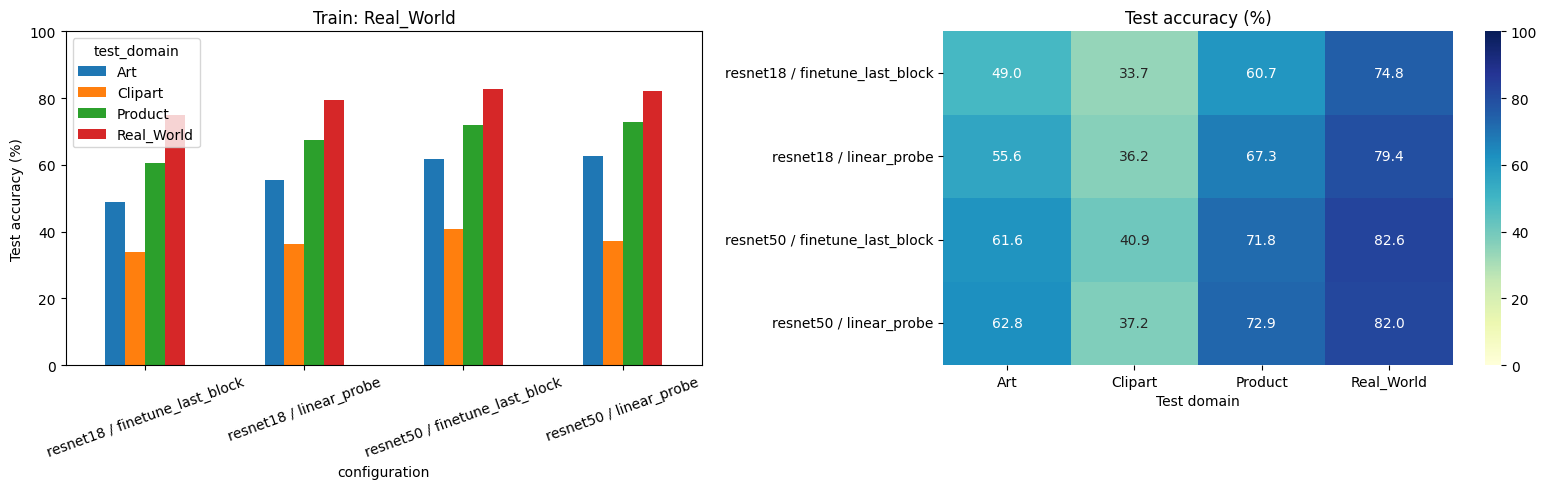

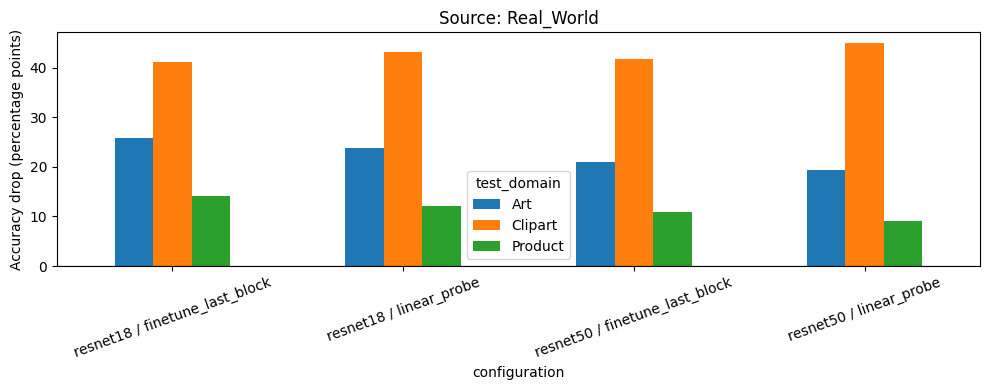

In [10]:
results=pd.read_csv(OUT / 'results_all.csv')
summary=results.groupby(['source','model','mode','test_domain'],as_index=False).agg(
    accuracy_mean=('accuracy','mean'),accuracy_std=('accuracy','std'),
    macro_f1_mean=('macro_f1','mean'),macro_f1_std=('macro_f1','std'),
    drop_pp_mean=('accuracy_drop_pp','mean'),n_seeds=('seed','nunique'))
summary.to_csv(OUT / 'summary.csv',index=False)
display(summary.round(4))
for source in SOURCE_DOMAINS:
    view=summary[summary.source==source].copy()
    view['configuration']=view.model+' / '+view['mode']
    table=view.pivot(index='configuration',columns='test_domain',values='accuracy_mean').reindex(columns=DOMAINS)*100
    fig,axes=plt.subplots(1,2,figsize=(16,5))
    table.plot.bar(ax=axes[0]); axes[0].set_ylabel('Test accuracy (%)')
    axes[0].set_ylim(0,100); axes[0].set_title(f'Train: {source}'); axes[0].tick_params(axis='x',rotation=20)
    sns.heatmap(table,annot=True,fmt='.1f',vmin=0,vmax=100,cmap='YlGnBu',ax=axes[1])
    axes[1].set_title('Test accuracy (%)'); axes[1].set_xlabel('Test domain'); axes[1].set_ylabel('')
    plt.tight_layout(); plt.savefig(OUT / f'accuracy_{source}.png',dpi=180); plt.show()
    drop=view[view.test_domain!=source].pivot(index='configuration',columns='test_domain',values='drop_pp_mean')
    ax=drop.plot.bar(figsize=(10,4)); ax.axhline(0,color='black',linewidth=.8)
    ax.set_ylabel('Accuracy drop (percentage points)'); ax.set_title(f'Source: {source}')
    ax.tick_params(axis='x',rotation=20)
    plt.tight_layout(); plt.savefig(OUT / f'domain_gap_{source}.png',dpi=180); plt.show()


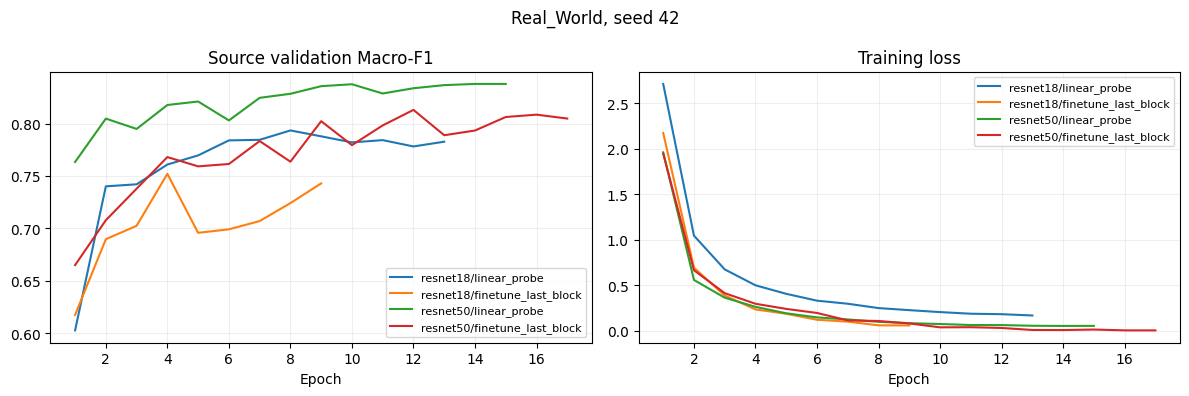

In [11]:
# Training curves: one figure per seed and source domain.
for source in SOURCE_DOMAINS:
    for seed in SEEDS:
        fig,axes=plt.subplots(1,2,figsize=(12,4))
        for name in MODEL_NAMES:
            for mode in MODES:
                exp=OUT / f'{source}__{name}__{mode}__seed{seed}'
                h=pd.read_csv(exp / 'history.csv')
                label=f'{name}/{mode}'
                axes[0].plot(h.epoch,h.val_macro_f1,label=label)
                axes[1].plot(h.epoch,h.train_loss,label=label)
        axes[0].set_title('Source validation Macro-F1'); axes[1].set_title('Training loss')
        for ax in axes:
            ax.set_xlabel('Epoch'); ax.legend(fontsize=8); ax.grid(alpha=.2)
        plt.suptitle(f'{source}, seed {seed}'); plt.tight_layout()
        plt.savefig(OUT / f'learning_curves_{source}_{seed}.png',dpi=160); plt.show()


## 8. Qualitative error analysis
A row-normalized confusion matrix identifies class-specific prediction patterns in the selected domain. Misclassified images with high softmax scores are displayed to support qualitative inspection of visual appearance and class confusion. Softmax scores are not calibrated probabilities of correctness.

The inspected configuration is specified independently of the training and model-selection procedure. Test-set inspection is used for post-experiment analysis rather than hyperparameter selection.

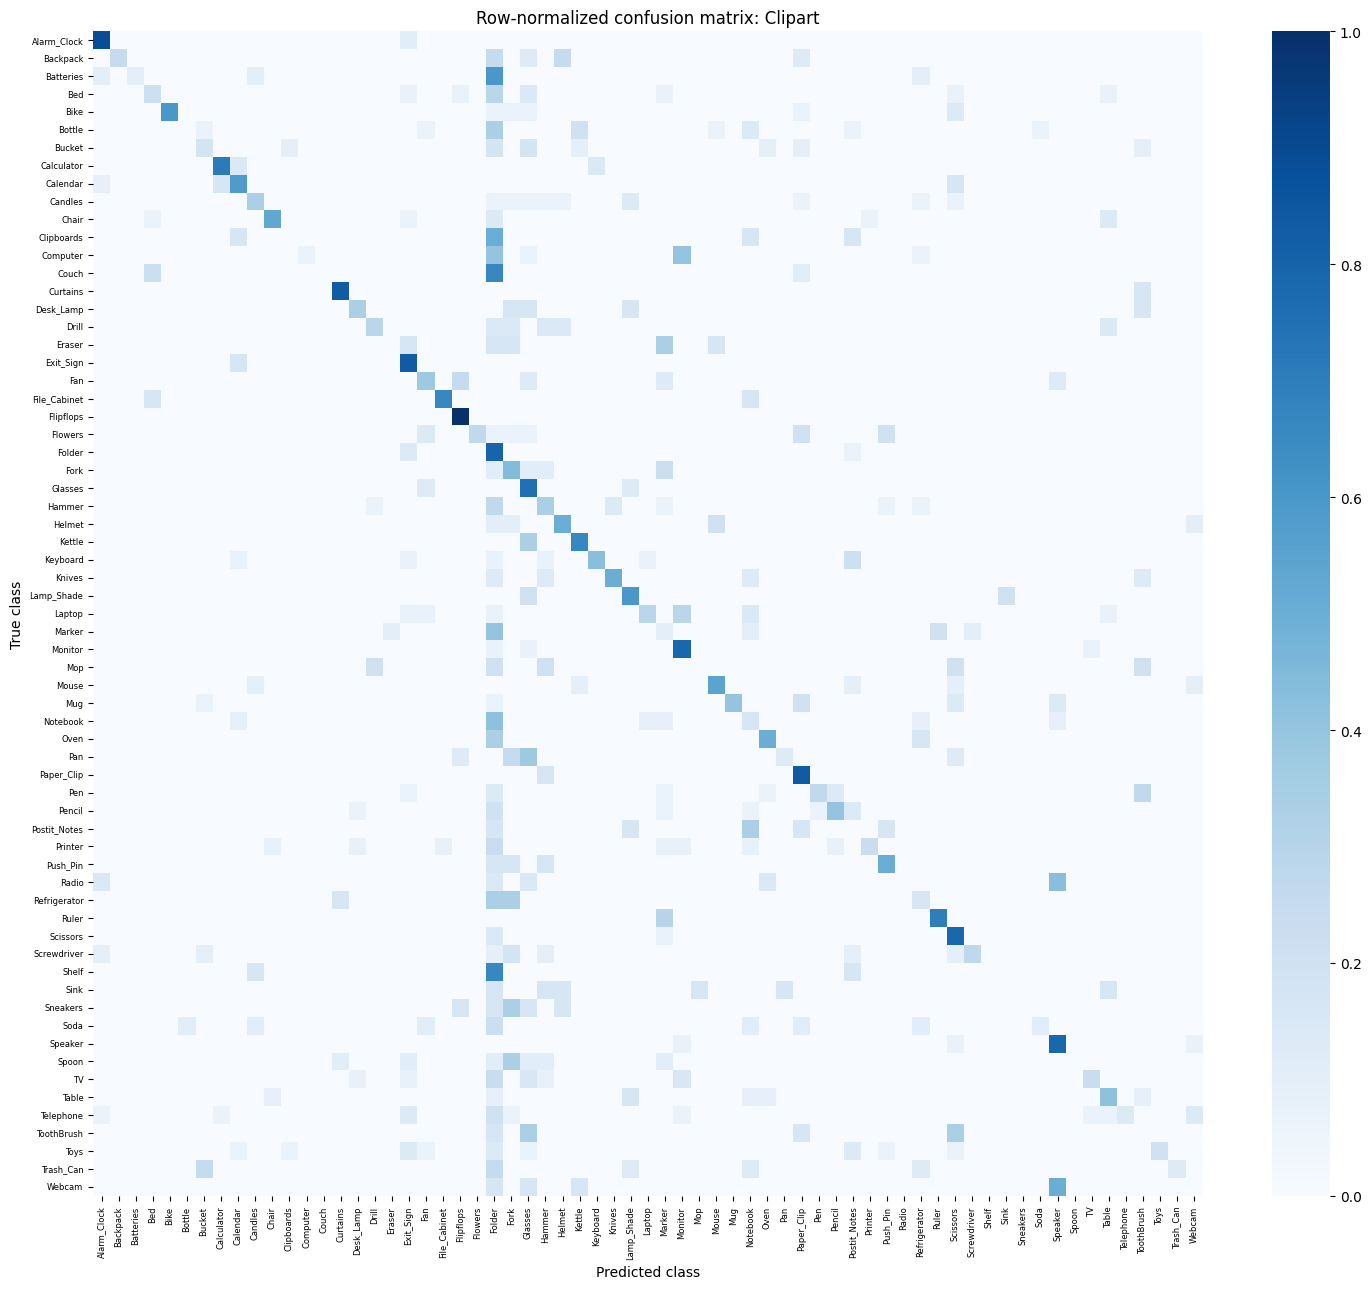

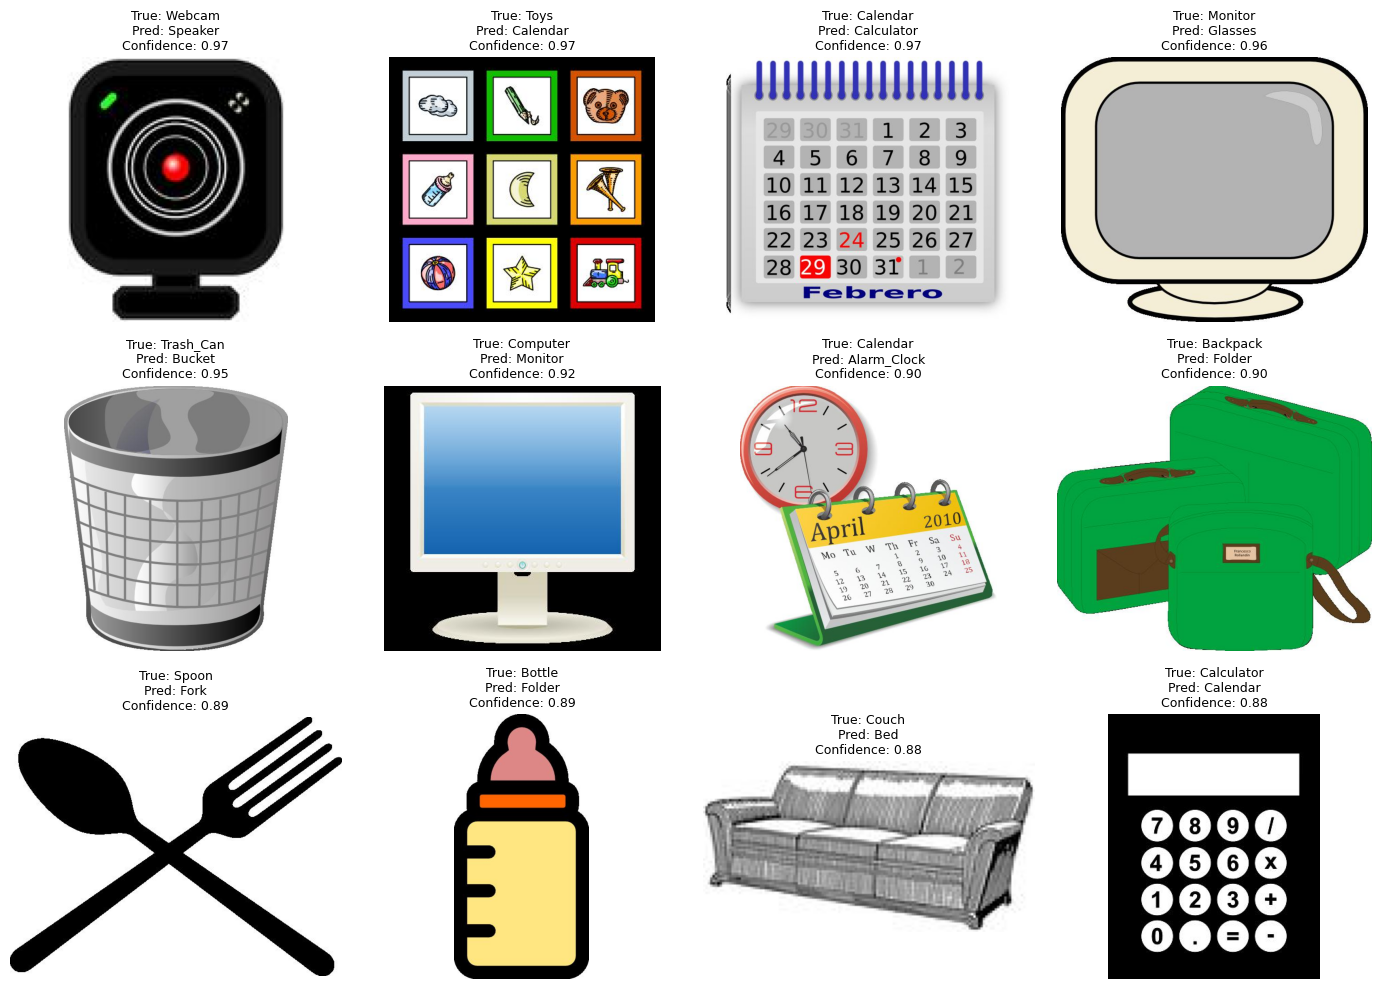

In [12]:
INSPECT_SOURCE = SOURCE_DOMAINS[0]
INSPECT_MODEL = MODEL_NAMES[0]
INSPECT_MODE = MODES[0]
INSPECT_SEED = SEEDS[0]
INSPECT_DOMAIN = 'Clipart'
exp=OUT / f'{INSPECT_SOURCE}__{INSPECT_MODEL}__{INSPECT_MODE}__seed{INSPECT_SEED}'
pred=pd.read_csv(exp / f'predictions_{INSPECT_DOMAIN}.csv')
cm=confusion_matrix(pred.y_true,pred.y_pred,labels=list(range(len(classes))))
row_sums=cm.sum(axis=1,keepdims=True)
cm_normalized=np.divide(cm,row_sums,out=np.zeros_like(cm,dtype=float),where=row_sums!=0)
fig,ax=plt.subplots(figsize=(15,13))
sns.heatmap(cm_normalized,vmin=0,vmax=1,cmap='Blues',xticklabels=classes,yticklabels=classes,ax=ax)
ax.tick_params(labelsize=6); ax.set_xlabel('Predicted class'); ax.set_ylabel('True class')
ax.set_title(f'Row-normalized confusion matrix: {INSPECT_DOMAIN}')
plt.tight_layout(); plt.savefig(OUT / f'confusion_{exp.name}_{INSPECT_DOMAIN}.png',dpi=200); plt.show()

errors=pred[pred.y_true!=pred.y_pred].sort_values('confidence',ascending=False).head(12)
if errors.empty:
    print('No misclassifications in the selected test set.')
else:
    fig,axes=plt.subplots(3,4,figsize=(14,10))
    for ax,(_,row) in zip(axes.flat,errors.iterrows()):
        with Image.open(DATA_ROOT / row.relative_path) as im: ax.imshow(im.convert('RGB'))
        ax.set_title(f'True: {row.true_class}\nPred: {row.predicted_class}\nConfidence: {row.confidence:.2f}',fontsize=9)
    for ax in axes.flat: ax.axis('off')
    plt.tight_layout(); plt.savefig(OUT / f'errors_{exp.name}_{INSPECT_DOMAIN}.png',dpi=160); plt.show()
# Softmax confidence is not a calibrated probability of correctness.


## 9. Results summary and interpretation
All four configurations completed on a Tesla T4. ResNet50 achieves higher test accuracy than ResNet18 under each matching training strategy across all four domains. Clipart has the lowest accuracy in every configuration. Fine-tuning reduces ResNet18 accuracy in every domain; for ResNet50 it improves Real-World and Clipart accuracy while reducing Art and Product accuracy slightly. These are single-seed observations, without statistical significance testing. The generated summary below reports the measured values.


In [13]:
lines=['# Experiment observations', '', f'Smoke test: {SMOKE_TEST}', f'Seeds: {SEEDS}', '']
for source in SOURCE_DOMAINS:
    view=summary[summary.source==source]
    for name in MODEL_NAMES:
        for mode in MODES:
            subset=view[(view.model==name)&(view['mode']==mode)]
            same=subset[subset.test_domain==source].iloc[0]
            lines.append(f'{source} / {name} / {mode}: same-domain accuracy = {same.accuracy_mean*100:.2f}%.')
            for _,r in subset[subset.test_domain!=source].iterrows():
                lines.append(f'  {r.test_domain}: accuracy {r.accuracy_mean*100:.2f}%, Macro-F1 {r.macro_f1_mean:.4f}, drop {r.drop_pp_mean:.2f} pp.')
    if set(MODES)=={'linear_probe','finetune_last_block'}:
        for name in MODEL_NAMES:
            pivot=view[view.model==name].pivot(index='test_domain',columns='mode',values='accuracy_mean')
            delta=(pivot['finetune_last_block']-pivot['linear_probe'])*100
            lines.append(f'Fine-tuning change for {name} (pp): '+', '.join(f'{d} {v:+.2f}' for d,v in delta.items()))
lines += ['', 'Limitations:',
          '- Source-only protocol; target labels were not used to train or select checkpoints.',
          '- Same-domain and cross-domain test sets differ in difficulty and composition.',
          '- Exact byte deduplication does not detect near-duplicate images.',
          '- Office-Home measures visual-style differences; no medical/satellite/industrial datasets were evaluated.',
          '- One seed does not measure training variability.' if len(SEEDS)==1 else '- Seed standard deviations measure training variation on one fixed split, not split variation.',
          '- Only the last residual block was fine-tuned; full-backbone fine-tuning was not evaluated.',
          '- ImageNet pretraining overlap with collected web images cannot be ruled out.']
text='\n'.join(lines)
(OUT / 'observations.md').write_text(text)
print(text)


# Experiment observations

Smoke test: False
Seeds: [42]

Real_World / resnet18 / linear_probe: same-domain accuracy = 79.42%.
  Art: accuracy 55.59%, Macro-F1 0.5182, drop 23.83 pp.
  Clipart: accuracy 36.22%, Macro-F1 0.3345, drop 43.19 pp.
  Product: accuracy 67.34%, Macro-F1 0.6550, drop 12.08 pp.
Real_World / resnet18 / finetune_last_block: same-domain accuracy = 74.81%.
  Art: accuracy 49.00%, Macro-F1 0.4423, drop 25.81 pp.
  Clipart: accuracy 33.75%, Macro-F1 0.3160, drop 41.06 pp.
  Product: accuracy 60.68%, Macro-F1 0.5828, drop 14.13 pp.
Real_World / resnet50 / linear_probe: same-domain accuracy = 82.03%.
  Art: accuracy 62.75%, Macro-F1 0.5898, drop 19.28 pp.
  Clipart: accuracy 37.15%, Macro-F1 0.3837, drop 44.88 pp.
  Product: accuracy 72.91%, Macro-F1 0.7150, drop 9.12 pp.
Real_World / resnet50 / finetune_last_block: same-domain accuracy = 82.64%.
  Art: accuracy 61.60%, Macro-F1 0.5781, drop 21.04 pp.
  Clipart: accuracy 40.87%, Macro-F1 0.4372, drop 41.78 pp.
  Product

## 10. Export of experimental outputs
The results archive contains split manifests, experiment settings, evaluation tables, per-class reports, training histories, figures, and generated observations. Model checkpoints are retained separately in the experiment output directory.

In [14]:
DOWNLOAD_RESULTS = True
archive_path=Path('/content') / f'{OUT.name}_results.zip'
with zipfile.ZipFile(archive_path,'w',compression=zipfile.ZIP_DEFLATED) as z:
    for p in OUT.rglob('*'):
        if p.is_file() and p.suffix not in {'.pt','.tmp'}:
            z.write(p,p.relative_to(OUT))
print('Results ZIP:',archive_path)
print('Checkpoints and all results:', OUT)
if DOWNLOAD_RESULTS:
    from google.colab import files
    files.download(str(archive_path))

Results ZIP: /content/run_5765dc922429_results.zip
Checkpoints and all results: /content/OfficeHome_DomainShift_T4/run_5765dc922429


## 11. Limitations
- The experiment evaluates visual-style differences in Office-Home. Its conclusions do not directly extend to medical, satellite, or industrial imagery.
- The held-out protocol differs from the standard Office-Home domain adaptation benchmark; results should not be compared directly with published benchmark scores.
- Domain test sets differ in sample composition and difficulty. Accuracy differences therefore cannot be attributed solely to domain shift.
- Exact byte-level deduplication does not detect near-duplicates. Overlap between ImageNet pretraining data and web-collected Office-Home images cannot be ruled out.
- The default single-seed experiment does not estimate training variability. Additional seeds assess variability on the same partition, rather than variability across data partitions.
- Only the final residual block is fine-tuned. Full-backbone fine-tuning and dedicated domain adaptation methods are outside the experimental scope.

## References
1. Venkateswara, H., Eusebio, J., Chakraborty, S., & Panchanathan, S. (2017). *Deep Hashing Network for Unsupervised Domain Adaptation*. Proceedings of the IEEE Conference on Computer Vision and Pattern Recognition, 5018–5027. [Paper](https://openaccess.thecvf.com/content_cvpr_2017/html/Venkateswara_Deep_Hashing_Network_CVPR_2017_paper.html)
2. [Office-Home dataset: description and original download](https://www.hemanthdv.org/officeHomeDataset.html).
3. PyTorch. [Torchvision ResNet18 documentation](https://docs.pytorch.org/vision/stable/models/generated/torchvision.models.resnet18.html).
4. PyTorch. [Torchvision ResNet50 documentation](https://docs.pytorch.org/vision/stable/models/generated/torchvision.models.resnet50.html).
5. PyTorch. [Automatic mixed precision examples](https://docs.pytorch.org/docs/stable/notes/amp_examples.html).

Office-Home is used under the authors' stated terms for noncommercial research and education.

Additional data source: [Flower Labs Office-Home mirror](https://huggingface.co/datasets/flwrlabs/office-home), pinned to commit `2a083645e3177afbd91ba4fa2651238f8994d335`.